In [1]:
# Setup 

%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib as plt

from preprocessing import (
    load_imu_data,
    load_annotations,
    align_annotations_to_imu,
    window_features,
    get_features_and_labels,
    check_class_balance,
    get_cv_splitter,
)

In [2]:
# Align IMU data with annotations:

imu_df = load_imu_data("a3_imu_data.csv")
annotations_df = load_annotations("a3_activity_annotations.csv")

labelled_df = align_annotations_to_imu(imu_df, annotations_df)
annotations_df.head

feature_df = window_features(labelled_df)
labelled_df.head()

,timestamp,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z,label
0,1.598240e+09,-2402,1710,-380,-1413,-362,223,Walking
1,1.598240e+09,-1880,1688,-420,-1469,-597,-23,Walking
2,1.598240e+09,-1558,1568,-606,-1535,-872,-195,Walking
3,1.598240e+09,-1154,1732,-654,-1293,-976,-335,Walking
4,1.598240e+09,-452,2084,-754,-719,-940,-214,Walking


In [3]:
# Feature Engineering

X, y = get_features_and_labels(
    imu_path="a3_imu_data.csv",
    annotations_path="a3_activity_annotations.csv",
    window_size_sec=1
)

# print and head for preview
print(f"Feature matrix: {X.shape}")
X.head


Feature matrix: (728, 21)


<bound method NDFrame.head of      accel_x_mean  accel_x_min  accel_x_max  accel_y_mean  accel_y_min  \
0    -2543.000000       -11338          350   3353.260000         -712   
1    -2743.600000       -18526         2634   3415.740000         -918   
2    -2613.760000        -6134         1258   3190.420000         -186   
3    -2484.200000        -3762        -1356   3262.900000         2596   
4    -2565.760000        -2990        -2182   3219.080000         2946   
..            ...          ...          ...           ...          ...   
723  -2844.360000       -11990         4710   3306.920000        -2060   
724  -2768.980000        -8942         3202   3316.020000        -2110   
725  -2253.280000        -6636           88   2883.560000         -150   
726  -2207.500000       -10632         2672   3362.020000         -868   
727  -2261.545455        -5172         1458   3322.878788          502   

     accel_y_max  accel_z_mean  accel_z_min  accel_z_max  gyro_x_mean  ...  \
0  

In [4]:
check_class_balance(y)

label
Jogging      201
Walking      197
Side-Step    115
Standing     110
Running      105
Name: count, dtype: int64

Classification Algorithms and Hyperparameter Tuning

Each algorithm is tuned using GridSearchCV using the same stratified K-fold splitter (preprocessing.get_cv_splitter()) so all three are trained and evaluated on identical folds for fair comparison.
Full training for each lives in its respective .py file, this section imports and presents an overview of the results. 

In [5]:
# Define cv variable so all algorithms run on identical data
cv = get_cv_splitter()

In [15]:
# KNN algorithm goes here

from knn import train_knn, knn_summary

knn_results = train_knn(X, y, cv=cv)
knn_summary_results = knn_summary(knn_results, X, y, cv=cv)

Best parameters: {'knn__n_neighbors': 9, 'knn__weights': 'distance'}
Best CV accuracy: 0.739

Clasification Report summary: 
              precision    recall  f1-score   support

     Jogging       0.74      0.87      0.80       201
     Running       0.75      0.76      0.76       105
   Side-Step       0.67      0.84      0.75       115
    Standing       0.44      0.04      0.07       110
     Walking       0.78      0.93      0.85       197

    accuracy                           0.74       728
   macro avg       0.68      0.69      0.64       728
weighted avg       0.70      0.74      0.69       728

Confusion Matrix: 
[[174   4  11   2  10]
 [ 17  80   4   1   3]
 [  5   0  97   2  11]
 [ 30  21  28   4  27]
 [  8   1   5   0 183]]


In [14]:
# SVC goes here

from svc import run_svc

svc_grid, svc_results = run_svc(X, y, cv=cv)


Best parameters: {'svc__C': 1, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}
Best CV accuracy: 0.742

Classification Report:
              precision    recall  f1-score   support

     Jogging       0.74      0.92      0.82       201
     Running       0.72      0.85      0.78       105
   Side-Step       0.65      0.77      0.71       115
    Standing       0.29      0.05      0.09       110
     Walking       0.86      0.87      0.87       197

    accuracy                           0.74       728
   macro avg       0.65      0.69      0.65       728
weighted avg       0.69      0.74      0.70       728

Confusion Matrix:
[[184   6   8   2   1]
 [  4  89   8   3   1]
 [ 13   1  89   8   4]
 [ 28  26  29   6  21]
 [ 20   1   2   2 172]]


In [16]:
# Random Forest goes here

from rforest import train_rforest, rforest_summary

rforest_results = train_rforest(X, y, cv=cv)
rforest_summary_results = rforest_summary(rforest_results, X, y, cv=cv)

Best parameters: {'rforest__max_leaf_nodes': 64, 'rforest__n_estimators': 250}
        Best CV accuracy: 0.749

Classification Report Summary: 
              precision    recall  f1-score   support

     Jogging       0.80      0.86      0.83       201
     Running       0.75      0.87      0.81       105
   Side-Step       0.63      0.77      0.69       115
    Standing       0.41      0.08      0.14       110
     Walking       0.81      0.92      0.86       197

    accuracy                           0.75       728
   macro avg       0.68      0.70      0.66       728
weighted avg       0.71      0.75      0.71       728

        Confusion Matrix: 
        [[173   2  14   2  10]
 [  0  91   8   3   3]
 [  9   1  89   7   9]
 [ 28  25  26   9  22]
 [  7   2   5   1 182]]


Model Visualizations

visualizations live in visualizations.py and are called here for each classification algorithm.

In [ ]:
# imports for visualizations, TODO: add to top later
from sklearn.model_selection import cross_val_predict
from visualizations import plot_confusion_matrix_comparison

In [ ]:
#Setup for visualization section

# defining consistent label order:
activity_labels = sorted(y.unique())

knn_pred = knn_summary_results["predictions"]
svc_pred = svc_results["predictions"]
rforest_pred = rforest_summary_results["predictions"]

knn_score = knn_results["best_score"]
rforest_score = rforest_results["best_score"]
svc_score = svc_grid.best_score_

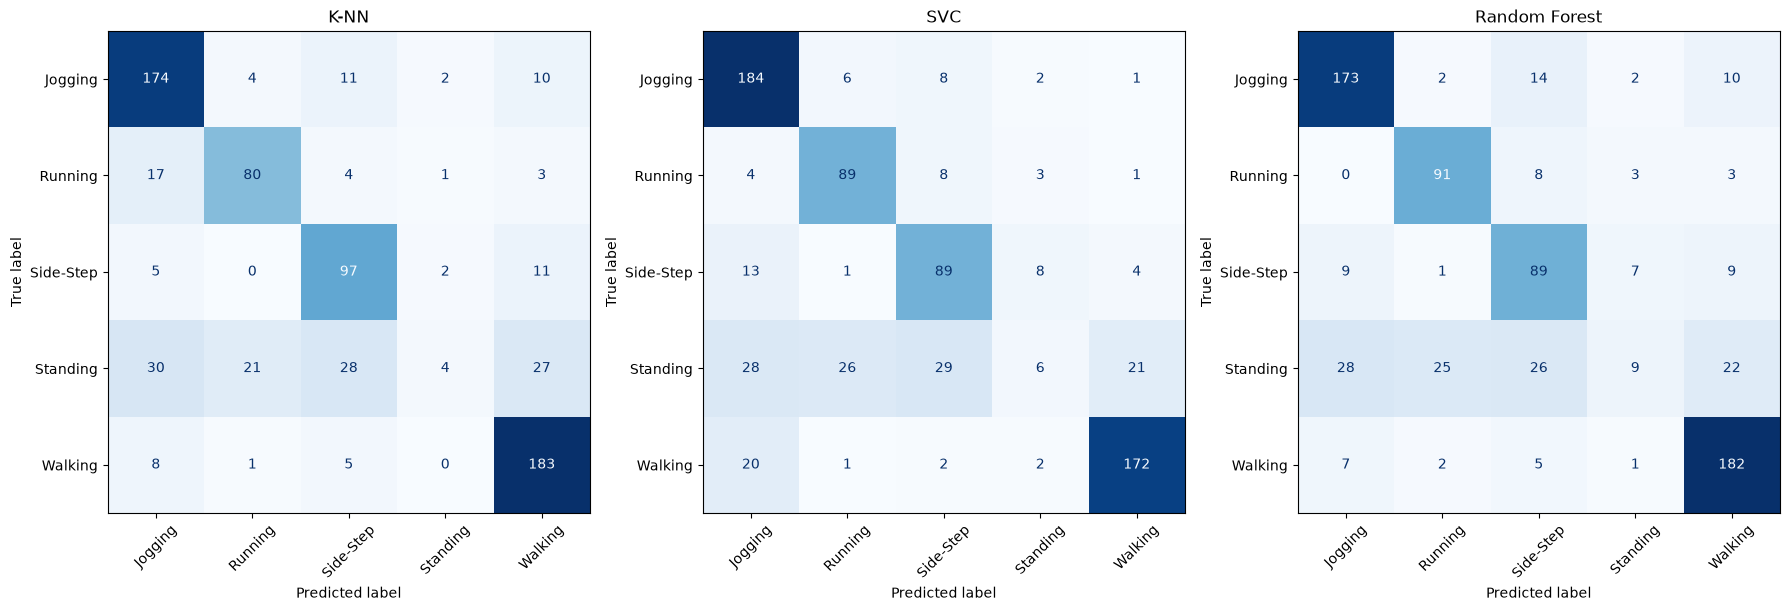

In [22]:
# confusion matrices

plot_confusion_matrix_comparison(
    predictions_by_model={
        "K-NN": knn_pred,
        "SVC": svc_pred,
        "Random Forest": rforest_pred,
    },
    y_true=y,
    labels=activity_labels
)

In [ ]:
# SVC

In [ ]:
# Random Forest